 # **$\text{Evaluación 2 — Redes neuronales y transformada de Fourier}$**
 $\text{Programación Científica 2026-1 · Universidad Nacional de Colombia}$

 $\text{Nombre: Shara Vergara Peréz}$

$\text{ID: 1067869851}$


# **$\text{PARTE 0. Carga de datos y librerias}$**



In [1]:
!python generar_enunciado.py 9851
!python generar_datos.py 9851

Enunciado generado para cédula 9851: enunciado_9851.md
Los parámetros: K=25, iteraciones=2000, η=0.02, n=12/régimen, régimen foco=1, compresión 85%
Datos generados para cédula 9851: X=(36, 256), y=(36,), t=(256,)
Guardado en datos_9851.npz


In [2]:
!sudo apt-get update
#Instala LaTeX (texlive) para que matplotlib pueda renderizar texto con usetex=True
!sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

import matplotlib.pyplot as plt  # graficas
import matplotlib.colors as mcolors  # utilidades de color (no se usa directamente aqui)
import numpy as np  # arreglos y algebra lineal en CPU (sin autodiff)
# --- JAX ---
import jax                         # libreria de autodiff + compilacion
import jax.numpy as jnp            # tipo NumPy, pero con arreglos que JAX puede diferenciar
from jax import grad, jit, vmap    # grad: deriva funciones; jit: compila para acelerar; vmap: vectoriza sin loops explicitos
import optax  # <-- Importamos la librería de optimizadores de Google (Lo usaremos más adelante para el Adam)

# Configuracion global de estilo para todas las figuras del notebook
plt.rcParams.update({
    "text.usetex": True,            # usar LaTeX real para renderizar texto/formulas
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 16,

    # Ejes y Ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid
    "grid.color"    : "gray",
    "grid.linewidth": 0.3,
    "grid.alpha"    : 0.3,
    "grid.linestyle": "--",

    # Estetica
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "savefig.bbox"      : "tight",
    "savefig.dpi"       : 300,
})


print('Configuracion OK')

Hit:1 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:5 https://cli.github.com/packages stable InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
cm-super is already the newest version (0.3.4-17).
dvipng is already the newest version (1.15-

In [3]:
# 1. Cargar el paquete de datos
datos = np.load('datos_9851.npz')

# Imprimir las llaves para ver exactamente cómo se llaman los archivos adentro
print("Archivos disponibles:", datos.files)

# 2. Extraer los arreglos usando las llaves correspondientes
t = datos['t.npy']  # Tu vector de tiempo de 256 puntos
X = datos['X.npy']  # Tus 36 señales (entradas de la red)
y = datos['y.npy']  # Las 36 etiquetas de los regímenes (0, 1 o 2)

# 3. Verificar que todo cargó correctamente
print(f"Dimensiones de t: {t.shape}") # Debería ser (256,)
print(f"Dimensiones de X: {X.shape}") # Debería ser (36, 256)
print(f"Dimensiones de y: {y.shape}") # Debería ser (36,)

print("Señales de Régimen 0:", (y == 0).sum())
print("Señales de Régimen 1:", (y == 1).sum())
print("Señales de Régimen 2:", (y == 2).sum())

Archivos disponibles: ['X', 'y', 't', 'meta']
Dimensiones de t: (256,)
Dimensiones de X: (36, 256)
Dimensiones de y: (36,)
Señales de Régimen 0: 12
Señales de Régimen 1: 12
Señales de Régimen 2: 12


# **$\text{PARTE 1. Capa Fourier}$**

*  $\text{La función que construye la capa Fourier ( $W_1$ con filas de senos y cosenos)}$.


In [4]:
def inicializar_W1_fourier(t, K=25):
    """
    Construye la matriz de inicialización de Fourier W1.
    Parámetros:
    t : jnp.ndarray
        El vector de tiempo de 256 puntos (cargado de datos_9851.npz).
    K : int
        Número de frecuencias. Para el ID 9851, K=25.
    Retorna:
    W1 : jnp.ndarray
        Matriz de pesos inicializada con dimensiones (2K, 256).
    """

    # 1. Crear el vector de números de onda k desde 1 hasta K
    # k tendrá dimensiones (25,)
    k = jnp.arange(1, K + 1)

    # 2. Preparar los argumentos para las funciones trigonométricas.
    # Necesitamos calcular 2 * pi * k * t para todas las combinaciones de k y t.
    # Usamos k[:, None] para cambiar su dimensión a (25, 1) y permitir el broadcasting con t que es (256,).
    # El resultado 'argumento' será una matriz de dimensiones (25, 256).
    argumento = 2 * jnp.pi * k[:, None] * t

    # 3. Calcular las matrices de senos y cosenos
    # Cada fila corresponderá a una frecuencia k diferente evaluada en todo el vector t.
    senos = jnp.sin(argumento)    # Dimensiones: (25, 256)
    cosenos = jnp.cos(argumento)  # Dimensiones: (25, 256)

    # 4. Concatenar ambas matrices a lo largo del eje 0 (filas) para formar W1
    # Primero irán las 25 filas de senos, y luego las 25 filas de cosenos.
    # El resultado final será de dimensiones (50, 256) que corresponde a (2K, 256).
    W1 = jnp.concatenate([senos, cosenos], axis=0)

    return W1

# Convertimos 't' a un arreglo de JAX para trabajar de forma nativa
t_jax = jnp.array(t)

# Creamos la matriz W1
W1_fourier = inicializar_W1_fourier(t_jax, K=25)

print(f"Dimensiones de W1: {W1_fourier.shape}") # Debería imprimir (50, 256)

Dimensiones de W1: (50, 256)


*  $\text{Evidencia de que, en su inicialización, la capa reproduce la transformada de Fourier de la señal (comparación con np.fft).}$

In [5]:
# =================================================================
# EVIDENCIA: Capa W1 vs Transformada de Fourier (np.fft.fft)
# =================================================================

# 1. Tomamos una sola señal de los datos para hacer la prueba
x_prueba = X[0] # X es tu matriz de datos de tamaño (36, 256)

# 2. Calculamos las proyecciones usando tu capa W1 (producto matricial)
proyeccion_W1 = jnp.dot(W1_fourier, x_prueba)

# Separamos los resultados: los primeros 25 son senos, los últimos 25 son cosenos
proy_senos = proyeccion_W1[:25]
proy_cosenos = proyeccion_W1[25:]

# Calculamos la magnitud combinada (amplitud real de cada frecuencia k)
magnitud_W1 = jnp.sqrt(proy_senos**2 + proy_cosenos**2)

# 3. Calculamos la FFT estándar usando .fft (como pidió tu profesor)
fft_estandar = jnp.fft.fft(x_prueba)

# Tomamos el valor absoluto (magnitud) de los números complejos de la FFT.
# IMPORTANTE: En la FFT completa, el índice 0 es la frecuencia media.
# Las frecuencias positivas (k=1 a 25) están exactamente en los índices del 1 al 25.
magnitud_fft = jnp.abs(fft_estandar[1:26])

# 4. Imprimimos la evidencia en forma de tabla
print("="*60)
print("EVIDENCIA: Capa W1 vs jnp.fft.fft (Magnitudes)")
print("="*60)
print(f"{'k (Frecuencia)':<15} | {'Magnitud Capa W1':<20} | {'Magnitud .fft':<20}")
print("-" * 60)

for k in range(25):
    # Imprimir fila por fila con 4 decimales para comparar
    print(f"{k+1:<15} | {magnitud_W1[k]:<20.4f} | {magnitud_fft[k]:<20.4f}")

print("="*60)

# 5. Métrica final contundente: Diferencia absoluta promedio
diferencia_promedio = jnp.mean(jnp.abs(magnitud_W1 - magnitud_fft))
print(f"-> Diferencia absoluta promedio entre ambos métodos: {diferencia_promedio:.6e}")

EVIDENCIA: Capa W1 vs jnp.fft.fft (Magnitudes)
k (Frecuencia)  | Magnitud Capa W1     | Magnitud .fft       
------------------------------------------------------------
1               | 18.7213              | 18.7213             
2               | 20.1627              | 20.1627             
3               | 24.5544              | 24.5544             
4               | 34.6759              | 34.6759             
5               | 69.7427              | 69.7427             
6               | 32.5274              | 32.5274             
7               | 54.9896              | 54.9896             
8               | 22.1338              | 22.1338             
9               | 14.0398              | 14.0398             
10              | 10.1388              | 10.1388             
11              | 7.6687               | 7.6687              
12              | 6.4176               | 6.4176              
13              | 5.0412               | 5.0412              
14              | 4.1946


*   $\text{Reporta la energía media del dataset ((X**2).mean(), con 3 decimales).}$



In [6]:
energia_media = (X**2).mean()
print("="*50)
print(f"La energía media del dataset es: {energia_media:.3f}")
print("="*50)

La energía media del dataset es: 0.670


# **$\text{PARTE 2. Entrenamiento y reconstrucción}$**

*  $\text{Gráfica: la señal original junto a su reconstrucción final, para una señal de cada régimen.)}$




Entrenando la red con ADAM por 2000 iteraciones...
¡Entrenamiento terminado!


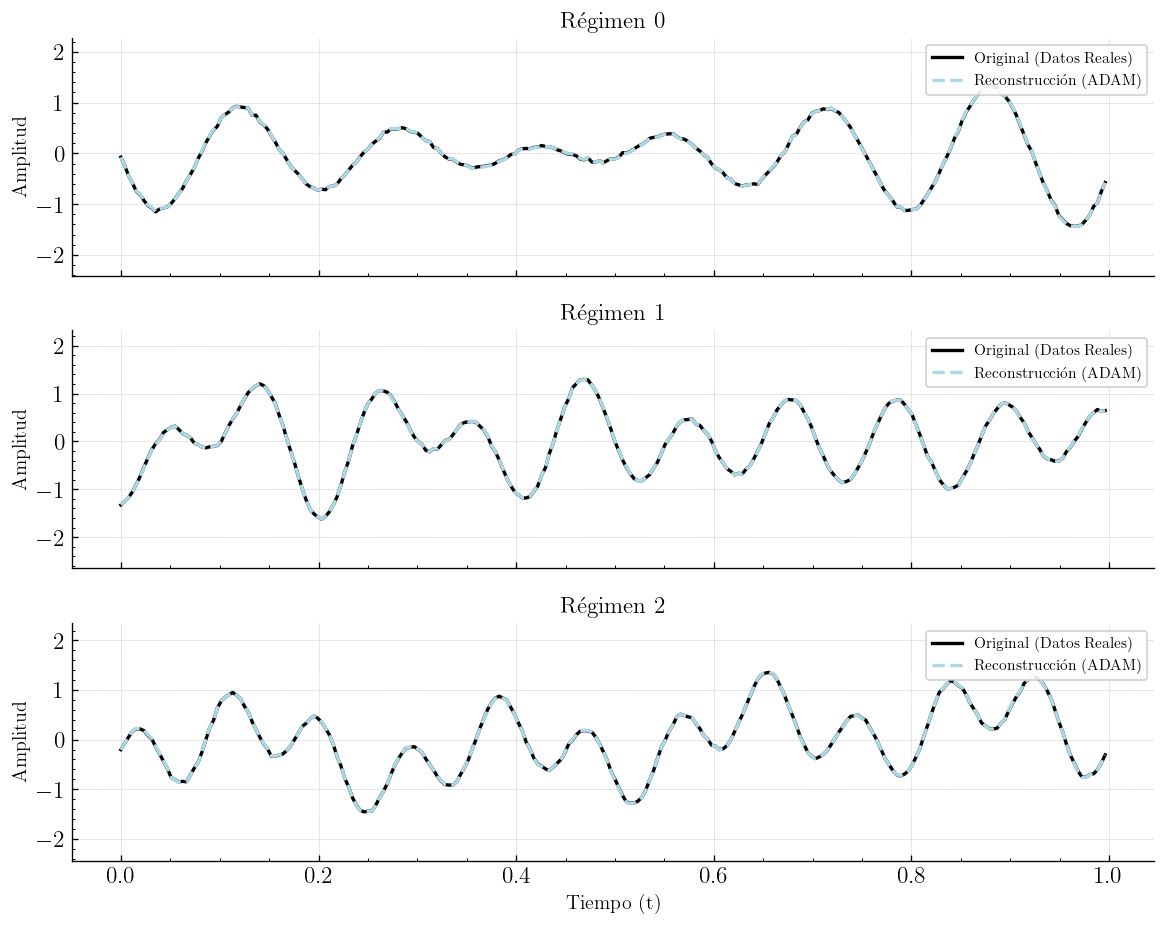

In [22]:
# =================================================================
# 1. DEFINIR LA RED Y CÓMO APRENDE
# =================================================================
def forward_pass(params, X_batch):
    # Capa 1: Fourier + Activación tanh
    activacion = jnp.tanh(jnp.dot(X_batch, params['W1'].T))
    # Capa 2: Reconstrucción Lineal
    return jnp.dot(activacion, params['W2'].T)

def loss_function(params, X_batch):
    X_pred = forward_pass(params, X_batch)
    return jnp.mean((X_pred - X_batch) ** 2)

# ---- AQUÍ ESTÁ ADAM ----
# Creamos el optimizador Adam con tu misma tasa de aprendizaje
optimizador = optax.adam(learning_rate=0.02)

@jax.jit
def update(params, opt_state, X_batch):
    # 1. Calcular el error y los gradientes
    loss, grads = jax.value_and_grad(loss_function)(params, X_batch)

    # 2. Adam calcula los pasos inteligentes usando los gradientes y su memoria (opt_state)
    updates, nuevo_opt_state = optimizador.update(grads, opt_state, params)

    # 3. Aplicar esos pasos inteligentes a nuestros pesos
    params_actualizados = optax.apply_updates(params, updates)

    return params_actualizados, nuevo_opt_state, loss

# =================================================================
# 2. INICIALIZAMOS Y ENTRENAMOS
# =================================================================
# Inicializar W2 con números aleatorios pequeños
key = jax.random.PRNGKey(42)
W2_init_f = jax.random.normal(key, shape=(256, 50)) * 0.01

# Agrupar los parámetros (Usamos W1_fourier)
params_opt_fourier = {'W1': W1_fourier, 'W2': W2_init_f}

# Inicializamos la "memoria" de Adam (para que pueda calcular la fricción e impulso)
opt_state = optimizador.init(params_opt_fourier)
print("="*50)
print("Entrenando la red con ADAM por 2000 iteraciones...")
for _ in range(2000):
    # Ahora le pasamos también el 'opt_state' en cada vuelta
    params_opt_fourier, opt_state, _ = update(params_opt_fourier, opt_state, X)
print("="*50)

print("¡Entrenamiento terminado!")
print("="*50)
# =================================================================
# 3. GRÁFICA: ORIGINAL VS RECONSTRUCCIÓN POR RÉGIMEN
# =================================================================
# Calculamos la reconstrucción final con los pesos ya entrenados
X_reconstruido = forward_pass(params_opt_fourier, X)

indices = [0, 12, 24] # Una señal de cada uno de tus 3 regímenes
nombres_regimenes = ["Régimen 0", "Régimen 1", "Régimen 2"]

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

for i, ax in enumerate(axes):
    idx = indices[i]
    # Original
    ax.plot(t, X[idx], label='Original (Datos Reales)', color='black', linewidth=2)
    # Reconstrucción
    ax.plot(t, X_reconstruido[idx], label='Reconstrucción (ADAM)', color='lightblue', linestyle='--', linewidth=2)

    ax.set_title(f'{nombres_regimenes[i]} ', fontsize=14, fontweight='bold')
    ax.set_ylabel('Amplitud', fontsize=12)

    # LEYENDA
    # 1. Agregamos margen vertical extra para que la curva no choque con la leyenda
    ax.margins(y=0.35)

    # 2. Hacemos la leyenda más pequeña y semitransparente
    ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
    # ---------------------------------------------

    ax.grid(True, linestyle=':', alpha=1)

plt.xlabel('Tiempo (t)', fontsize=12)
plt.tight_layout()
plt.show()



*   $\text{Red entrenada con las dos inicializaciones (Fourier y aleatoria), con los parámetros del enunciado.}$





In [8]:
# =================================================================
# 1. DEFINICIÓN DE LA RED Y SU ENTRENAMIENTO
# =================================================================
def forward_pass(params, X_batch):
    activacion = jnp.tanh(jnp.dot(X_batch, params['W1'].T))
    return jnp.dot(activacion, params['W2'].T)

def loss_function(params, X_batch):
    X_pred = forward_pass(params, X_batch)
    return jnp.mean((X_pred - X_batch) ** 2)

@jax.jit
def update(params, X_batch, lr=0.02):
    loss, grads = jax.value_and_grad(loss_function)(params, X_batch)
    params_actualizados = jax.tree_util.tree_map(lambda p, g: p - lr * g, params, grads)
    return params_actualizados, loss

# =================================================================
# 2. PREPARACIÓN DE LAS DOS INICIALIZACIONES
# =================================================================
key = jax.random.PRNGKey(42)
key_w1_rand, key_w2_f, key_w2_r = jax.random.split(key, 3)

# ---- RED A: Inicialización Fourier ----
W2_init_f = jax.random.normal(key_w2_f, shape=(256, 50)) * 0.01
params_opt_fourier = {'W1': W1_fourier, 'W2': W2_init_f}

# ---- RED B: Inicialización Aleatoria ----
W1_random = jax.random.normal(key_w1_rand, shape=(50, 256)) * 0.1
W2_init_r = jax.random.normal(key_w2_r, shape=(256, 50)) * 0.01
params_opt_random = {'W1': W1_random, 'W2': W2_init_r}

# =================================================================
# 3. ENTRENAMIENTO DE AMBAS REDES 2000 iteraciones, lr=0.02)
# =================================================================
print("Entrenando Red Fourier por 2000 iteraciones...")
for _ in range(2000):
    params_opt_fourier, _ = update(params_opt_fourier, X, lr=0.02)

print("Entrenando Red Aleatoria por 2000 iteraciones...")
for _ in range(2000):
    params_opt_random, _ = update(params_opt_random, X, lr=0.02)

print("¡Ambas redes entrenadas con éxito!\n")

# =================================================================
# 4. COMPARACIÓN DE RECONSTRUCCIONES
# =================================================================
# Obtenemos las predicciones finales de ambos mundos
X_rec_fourier = forward_pass(params_opt_fourier, X)
X_rec_random = forward_pass(params_opt_random, X)

indices = [0, 12, 24] # Una señal de cada régimen
nombres_regimenes = ["Régimen 0", "Régimen 1", "Régimen 2"]

print("="*75)
print(" CONTRASTE DE RECONSTRUCCIÓN: FOURIER VS ALEATORIA (2000 iteraciones)")
print("="*75)
print(f"{'Régimen (Índice)':<25} | {'Error Relativo Fourier':<22} | {'Error Relativo Aleatoria':<22}")
print("-" * 75)

for i, idx in enumerate(indices):
    # Calculamos la norma (tamaño) de la señal original
    norma_original = jnp.linalg.norm(X[idx])

    # Calculamos el error relativo para esta señal específica en ambas redes
    err_fourier = jnp.linalg.norm(X_rec_fourier[idx] - X[idx]) / norma_original
    err_random = jnp.linalg.norm(X_rec_random[idx] - X[idx]) / norma_original

    nombre_fila = f"{nombres_regimenes[i]} (Señal {idx})"

    # Imprimimos la fila con los resultados alineados
    print(f"{nombre_fila:<25} | {err_fourier:<22.4f} | {err_random:<22.4f}")

print("="*75)

Entrenando Red Fourier por 2000 iteraciones...
Entrenando Red Aleatoria por 2000 iteraciones...
¡Ambas redes entrenadas con éxito!

 CONTRASTE DE RECONSTRUCCIÓN: FOURIER VS ALEATORIA (2000 iteraciones)
Régimen (Índice)          | Error Relativo Fourier | Error Relativo Aleatoria
---------------------------------------------------------------------------
Régimen 0 (Señal 0)       | 0.6631                 | 0.6155                
Régimen 1 (Señal 12)      | 0.8118                 | 0.6205                
Régimen 2 (Señal 24)      | 0.8595                 | 0.7309                




*  $\text{Error de reconstrucción relativo |x^-x|/|x| reportado para cada caso.}$




In [9]:
# =================================================================
# CÁLCULO DEL ERROR DE RECONSTRUCCIÓN RELATIVO
# =================================================================

def calcular_error_relativo(X_real, X_pred):
    """
    Calcula el error relativo por señal usando la norma L2 (Euclidiana).
    Fórmula: ||X_pred - X_real|| / ||X_real||
    """
    norma_del_error = jnp.linalg.norm(X_pred - X_real, axis=1)
    norma_original = jnp.linalg.norm(X_real, axis=1)
    return norma_del_error / norma_original

# 1. Generamos las predicciones finales de ambas redes
X_pred_fourier = forward_pass(params_opt_fourier, X)
X_pred_random = forward_pass(params_opt_random, X)

# 2. Calculamos los errores relativos para cada una de las 36 señales
errores_fourier = calcular_error_relativo(X, X_pred_fourier)
errores_random = calcular_error_relativo(X, X_pred_random)

# 3. Reportamos el promedio general y por cada régimen
print("="*50)
print("REPORTES DE ERROR RELATIVO MULTICASO")
print("="*50)
print(f"Error Relativo Promedio - RED FOURIER : {jnp.mean(errores_fourier):.5f}")
print(f"Error Relativo Promedio - RED ALEATORIA: {jnp.mean(errores_random):.5f}")
print("-"*50)

# Desglosado por régimen (asumiendo bloques de 12 señales)
print("Desglose por Regímenes (Red Fourier):")
print(f"  -> Régimen 0 (Señales 0-11) : {jnp.mean(errores_fourier[0:12]):.5f}")
print(f"  -> Régimen 1 (Señales 12-23): {jnp.mean(errores_fourier[12:24]):.5f}")
print(f"  -> Régimen 2 (Señales 24-35): {jnp.mean(errores_fourier[24:36]):.5f}")
print("="*50)

REPORTES DE ERROR RELATIVO MULTICASO
Error Relativo Promedio - RED FOURIER : 0.76450
Error Relativo Promedio - RED ALEATORIA: 0.64786
--------------------------------------------------
Desglose por Regímenes (Red Fourier):
  -> Régimen 0 (Señales 0-11) : 0.78936
  -> Régimen 1 (Señales 12-23): 0.76927
  -> Régimen 2 (Señales 24-35): 0.73486




# **$\text{PARTE 3. Comparación de inicializaciones}$**

*  $\text{Gráfica: curvas de la pérdida L vs iteraciones, con las dos inicializaciones superpuestas en la misma figura.)}$


Entrenando red con inicialización de Fourier por 2000 iteraciones...
Entrenando red con inicialización Aleatoria por 2000 iteraciones...


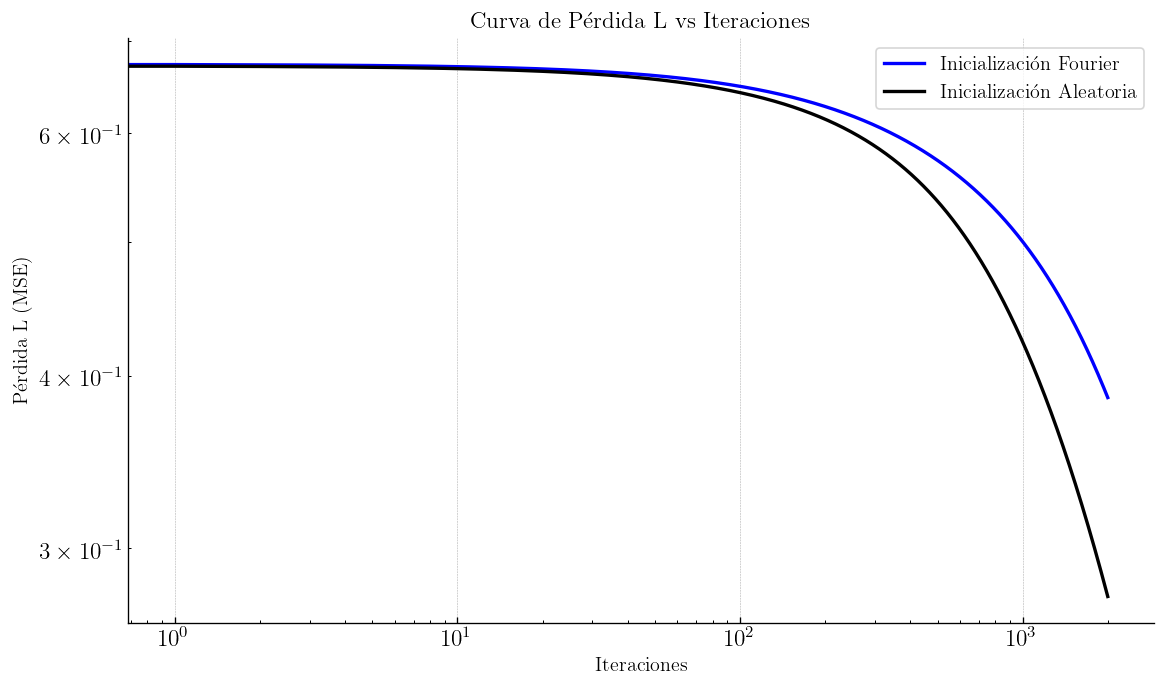

In [10]:
# =================================================================
# 1. DEFINICIÓN DE FUNCIONES (Modelo y Entrenamiento)
# =================================================================
def forward_pass(params, X_batch):
    activacion = jnp.tanh(jnp.dot(X_batch, params['W1'].T))
    return jnp.dot(activacion, params['W2'].T)

def loss_function(params, X_batch):
    X_pred = forward_pass(params, X_batch)
    return jnp.mean((X_pred - X_batch) ** 2)

@jax.jit
def update(params, X_batch, lr=0.02):
    loss, grads = jax.value_and_grad(loss_function)(params, X_batch)
    # Actualiza todas las capas que no estén congeladas (aquí actualiza ambas)
    params_actualizados = jax.tree_util.tree_map(lambda p, g: p - lr * g, params, grads)
    return params_actualizados, loss

def entrenar_red(params_iniciales, X_batch, iteraciones=2000, lr=0.02):
    params = params_iniciales
    historial_loss = []

    for _ in range(iteraciones):
        params, loss = update(params, X_batch, lr)
        historial_loss.append(loss)

    return params, jnp.array(historial_loss)

# =================================================================
# 2. PREPARACIÓN DE LAS DOS INICIALIZACIONES
# =================================================================
key = jax.random.PRNGKey(42)
key_w1_rand, key_w2_f, key_w2_r = jax.random.split(key, 3)

# ---- INICIALIZACIÓN A: Fourier ----
# Usamos tu W1_fourier (fija o entrenable, según pida el enunciado, aquí se entrena desde Fourier)
W2_init_f = jax.random.normal(key_w2_f, shape=(256, 50)) * 0.01
params_fourier = {'W1': W1_fourier, 'W2': W2_init_f}

# ---- INICIALIZACIÓN B: Aleatoria ----
# Reemplazamos W1 por puros números al azar para comparar
W1_random = jax.random.normal(key_w1_rand, shape=(50, 256)) * 0.1
W2_init_r = jax.random.normal(key_w2_r, shape=(256, 50)) * 0.01
params_random = {'W1': W1_random, 'W2': W2_init_r}

# =================================================================
# 3. EJECUCIÓN DEL ENTRENAMIENTO (2000 Iteraciones)
# =================================================================
print("="*70)
print("Entrenando red con inicialización de Fourier por 2000 iteraciones...")
params_opt_fourier, loss_hist_fourier = entrenar_red(params_fourier, X, iteraciones=2000, lr=0.02)
print("="*70)
print("Entrenando red con inicialización Aleatoria por 2000 iteraciones...")
params_opt_random, loss_hist_random = entrenar_red(params_random, X, iteraciones=2000, lr=0.02)
print("="*70)
# =================================================================
# 4. ENTREGABLE RÚBRICA: Gráfica de Pérdida L Superpuesta
# =================================================================
plt.figure(figsize=(10, 6))

# Graficamos los dos historiales de pérdida en la misma figura
plt.plot(loss_hist_fourier, label='Inicialización Fourier', color='blue', linewidth=2)
plt.plot(loss_hist_random, label='Inicialización Aleatoria', color='black', linewidth=2)

plt.title('Curva de Pérdida L vs Iteraciones', fontsize=14, fontweight='bold')
plt.xlabel('Iteraciones', fontsize=12)
plt.ylabel('Pérdida L (MSE)', fontsize=12)

# porque el error cae tan rápido que en escala normal no se apreciaría bien el detalle.
plt.yscale('log')
plt.xscale('log')

# Leyenda
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



*   $\text{Medición de cuántas iteraciones necesita cada inicialización para que el error relativo 0.1. }$



In [11]:
# =================================================================
# 1. RE-DEFINIMOS LAS FUNCIONES BASE PARA EVITAR ERRORES DE MEMORIA
# =================================================================
def forward_pass(params, X_batch):
    activacion = jnp.tanh(jnp.dot(X_batch, params['W1'].T))
    return jnp.dot(activacion, params['W2'].T)

def loss_function(params, X_batch):
    X_pred = forward_pass(params, X_batch)
    return jnp.mean((X_pred - X_batch) ** 2)

@jax.jit
def update_y_calcular_error(params, X_batch, lr=0.02):
    # Paso de entrenamiento
    loss, grads = jax.value_and_grad(loss_function)(params, X_batch)
    params_actualizados = jax.tree_util.tree_map(lambda p, g: p - lr * g, params, grads)

    # Cálculo del error relativo promedio
    X_pred = forward_pass(params_actualizados, X_batch)
    norma_del_error = jnp.linalg.norm(X_pred - X_batch, axis=1)
    norma_original = jnp.linalg.norm(X_batch, axis=1)
    error_relativo_promedio = jnp.mean(norma_del_error / norma_original)

    return params_actualizados, error_relativo_promedio

# =================================================================
# 2. NUEVA FUNCIÓN DE MEDICIÓN CON REPORTE EN VIVO
# =================================================================
def medir_convergencia_real(params_iniciales, X_batch, nombre_red, max_iteraciones=45000, lr=0.02, objetivo=0.1):
    params = params_iniciales
    iteracion_exacta = None

    print(f"\n>>> INICIANDO ENTRENAMIENTO DE: {nombre_red} <<<")
    print("Buscando la iteración donde el error sea menor a 0.1...")

    for i in range(max_iteraciones):
        params, err_relativo = update_y_calcular_error(params, X_batch, lr)

        # Te avisa cómo va el error cada 1000 pasos para que veas el progreso
        if (i + 1) % 1000 == 0:
            print(f"  -> Iteración {i+1}: El error va en {err_relativo:.4f}")

        # Si logra bajar de 0.1, guarda la iteración, nos avisa y rompe el bucle de inmediato
        if err_relativo < objetivo:
            iteracion_exacta = i + 1
            print(f"  ¡META LOGRADA! El error bajó de 0.1 en la iteración número: {iteracion_exacta}")
            break

    if iteracion_exacta is None:
        print(f"  AVISO: Tras {max_iteraciones} iteraciones, el error se quedó en {err_relativo:.4f} y no bajó de 0.1")

    return iteracion_exacta

# =================================================================
# 3. PREPARAR REDES DESDE CERO (Limpias para empezar la carrera)
# =================================================================
key = jax.random.PRNGKey(42)
key_w1_rand, key_w2_f, key_w2_r = jax.random.split(key, 3)

# Red Fourier
W2_init_f = jax.random.normal(key_w2_f, shape=(256, 50)) * 0.01
params_fourier_limpios = {'W1': W1_fourier, 'W2': W2_init_f}

# Red Aleatoria
W1_random = jax.random.normal(key_w1_rand, shape=(50, 256)) * 0.1
W2_init_r = jax.random.normal(key_w2_r, shape=(256, 50)) * 0.01
params_random_limpios = {'W1': W1_random, 'W2': W2_init_r}

# =================================================================
# 4. EJECUTAR LA MEDICIÓN CON EL NUEVO LÍMITE DE 30,000
# =================================================================
iter_fourier = medir_convergencia_real(params_fourier_limpios, X, "RED FOURIER", max_iteraciones=45000)
iter_random = medir_convergencia_real(params_random_limpios, X, "RED ALEATORIA", max_iteraciones=45000)

# =================================================================
# 5. RESUMEN FINAL PARA TU REPORTE
# =================================================================
print("\n" + "="*60)
print("             CONCLUSIÓN")
print("="*60)
print(f"Iteraciones Red Fourier  : {iter_fourier if iter_fourier else 'No alcanzó (Se estancó)'}")
print(f"Iteraciones Red Aleatoria: {iter_random if iter_random else 'No alcanzó (Se estancó)'}")
print("="*60)


>>> INICIANDO ENTRENAMIENTO DE: RED FOURIER <<<
Buscando la iteración donde el error sea menor a 0.1...
  -> Iteración 1000: El error va en 0.8638
  -> Iteración 2000: El error va en 0.7645
  -> Iteración 3000: El error va en 0.6816
  -> Iteración 4000: El error va en 0.6122
  -> Iteración 5000: El error va en 0.5551
  -> Iteración 6000: El error va en 0.5074
  -> Iteración 7000: El error va en 0.4668
  -> Iteración 8000: El error va en 0.4324
  -> Iteración 9000: El error va en 0.4030
  -> Iteración 10000: El error va en 0.3774
  -> Iteración 11000: El error va en 0.3545
  -> Iteración 12000: El error va en 0.3341
  -> Iteración 13000: El error va en 0.3158
  -> Iteración 14000: El error va en 0.2995
  -> Iteración 15000: El error va en 0.2842
  -> Iteración 16000: El error va en 0.2707
  -> Iteración 17000: El error va en 0.2585
  -> Iteración 18000: El error va en 0.2473
  -> Iteración 19000: El error va en 0.2371
  -> Iteración 20000: El error va en 0.2275
  -> Iteración 21000: El



*    $\text{Gráfica/análisis del régimen indicado: contrastar velocidad de convergencia para el régimen que indica el enunciado.}$






Analizando convergencia en el Régimen 1 (2000 iteraciones)...


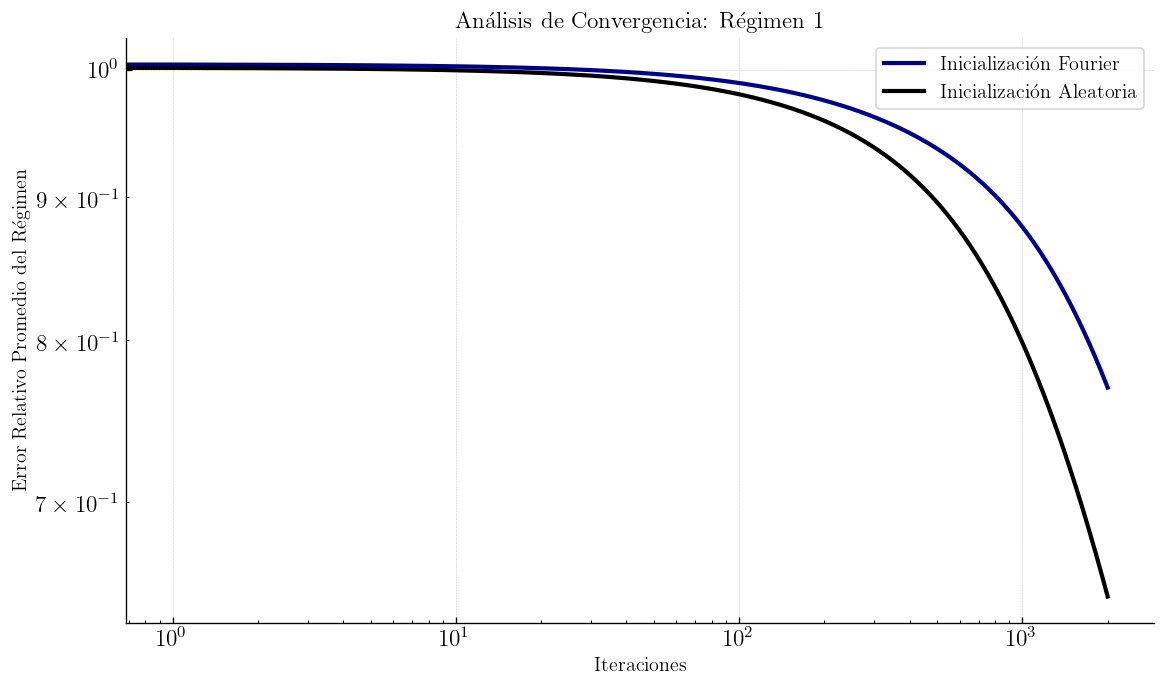

In [12]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

# =================================================================
# 1. ENTRENAMIENTO RASTREANDO SOLO EL RÉGIMEN 1 (Señales 12-23)
# =================================================================
def entrenar_rastreando_regimen(params_iniciales, X_batch, max_iter=2000, lr=0.02):
    params = params_iniciales
    historial_error_regimen = []

    for _ in range(max_iter):
        # Actualizamos pesos usando TODO el dataset
        params, _ = update_y_calcular_error(params, X_batch, lr)

        # Pero calculamos el error relativo para el Régimen 1 (índices 12 al 23)
        X_pred = forward_pass(params, X_batch)

        # Aislamos las señales del Régimen 1
        X_real_regimen = X_batch[12:24]
        X_pred_regimen = X_pred[12:24]

        # Calculamos el error relativo promedio exclusivo de este grupo
        norma_err = jnp.linalg.norm(X_pred_regimen - X_real_regimen, axis=1)
        norma_orig = jnp.linalg.norm(X_real_regimen, axis=1)
        error_relativo_regimen = jnp.mean(norma_err / norma_orig)

        historial_error_regimen.append(error_relativo_regimen)

    return jnp.array(historial_error_regimen)

# =================================================================
# 2. EJECUTAMOS EL RASTREO PARA AMBAS REDES
# =================================================================
# Re-inicializamos limpio
key = jax.random.PRNGKey(42)
key_w1_rand, key_w2_f, key_w2_r = jax.random.split(key, 3)

params_f = {'W1': W1_fourier, 'W2': jax.random.normal(key_w2_f, shape=(256, 50)) * 0.01}
params_r = {'W1': jax.random.normal(key_w1_rand, shape=(50, 256)) * 0.1, 'W2': jax.random.normal(key_w2_r, shape=(256, 50)) * 0.01}
print("="*60)
print("Analizando convergencia en el Régimen 1 (2000 iteraciones)...")
print("="*60)
hist_fourier_regimen = entrenar_rastreando_regimen(params_f, X, max_iter=2000)
hist_random_regimen = entrenar_rastreando_regimen(params_r, X, max_iter=2000)

# =================================================================
# 3. ENTREGABLE: GRÁFICA DE CONVERGENCIA DEL RÉGIMEN 1
# =================================================================
plt.figure(figsize=(10, 6))
plt.plot(hist_fourier_regimen, label='Inicialización Fourier', color='darkblue', linewidth=2.5)
plt.plot(hist_random_regimen, label='Inicialización Aleatoria', color='black', linewidth=2.5)

plt.title('Análisis de Convergencia: Régimen 1', fontsize=14, fontweight='bold')
plt.xlabel('Iteraciones', fontsize=12)
plt.ylabel('Error Relativo Promedio del Régimen', fontsize=12)
plt.yscale('log') # Escala logarítmica para ver la diferencia fina
plt.xscale('log')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()



   
# **$\text{PARTE 4. Compresión}$**

*  $\text{Gráfica: error de reconstrucción vs número de coeficientes conservados.}$
* $\text{Cuántos coeficientes bastan para lograr umbral de energía del enunciado.}$





Calculando errores de compresión y buscando el umbral del 85% de energía...
 -> Para garantizar un 85% de energía, se necesitan retener 11 coeficientes.
 -> El error relativo promedio en ese punto es de: 0.1378


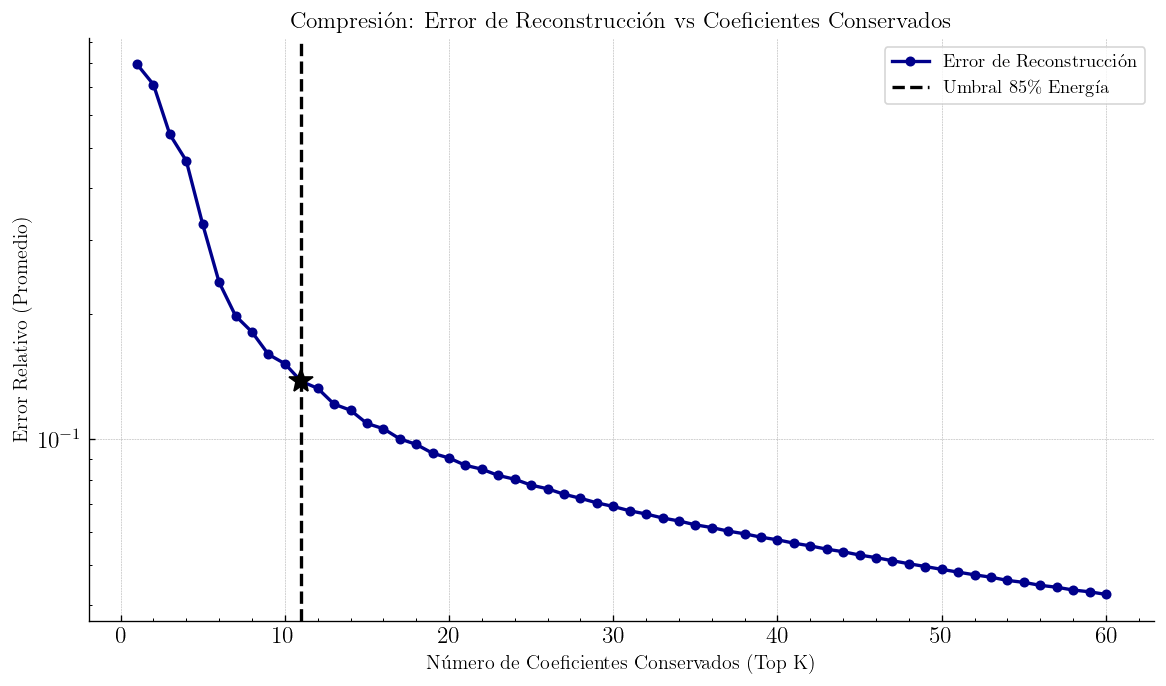

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# 1. FUNCIONES DE CÁLCULO (Compresión y Energía)
# =================================================================
def calcular_curva_compresion(X_data, max_coeficientes=60):
    errores_promedio = []
    X_fft = np.fft.fft(X_data, axis=1)
    rango_k = range(1, max_coeficientes + 1)

    for k in rango_k:
        X_fft_comprimida = np.zeros_like(X_fft)
        for i in range(X_data.shape[0]):
            indices_top_k = np.argsort(np.abs(X_fft[i]))[-k:]
            X_fft_comprimida[i, indices_top_k] = X_fft[i, indices_top_k]

        X_rec = np.real(np.fft.ifft(X_fft_comprimida, axis=1))
        norma_err = np.linalg.norm(X_rec - X_data, axis=1)
        norma_orig = np.linalg.norm(X_data, axis=1)
        errores_promedio.append(np.mean(norma_err / norma_orig))

    return list(rango_k), errores_promedio

def coeficientes_para_umbral_energia(X_data, umbral=0.85):
    X_fft = np.fft.fft(X_data, axis=1)
    energia = np.abs(X_fft)**2
    energia_ordenada = np.sort(energia, axis=1)[:, ::-1]

    energia_total = np.sum(energia_ordenada, axis=1, keepdims=True)
    energia_acumulada = np.cumsum(energia_ordenada, axis=1) / energia_total

    coefs_necesarios = []
    for i in range(X_data.shape[0]):
        idx = np.argmax(energia_acumulada[i] >= umbral) + 1
        coefs_necesarios.append(idx)

    return np.array(coefs_necesarios)

# =================================================================
# 2. EJECUTAR EL CÁLCULO DE COMPRESIÓN Y UMBRAL 85%
# =================================================================
print("="*75)
print("Calculando errores de compresión y buscando el umbral del 85% de energía...")

# 1. Calculamos la curva general
coefs_conservados, errores_compresion = calcular_curva_compresion(X, max_coeficientes=60)

# 2. Calculamos los coeficientes exactos para el 85%
umbral_energia = 0.85
coefs_por_senal = coeficientes_para_umbral_energia(X, umbral=umbral_energia)

# Tomamos el MÁXIMO para garantizar que todas las señales cumplan el 85%
k_85 = int(np.max(coefs_por_senal))
error_en_k_85 = errores_compresion[k_85 - 1] # Buscamos el error exacto en ese punto (índice k-1)

print(f" -> Para garantizar un 85% de energía, se necesitan retener {k_85} coeficientes.")
print(f" -> El error relativo promedio en ese punto es de: {error_en_k_85:.4f}")
print("="*75)

# =================================================================
# 3. ENTREGABLE: GRÁFICA DE COMPRESIÓN
# =================================================================
plt.figure(figsize=(10, 6))

# Dibujamos la curva de error vs coeficientes
plt.plot(coefs_conservados, errores_compresion, marker='o', color='darkblue',
         linestyle='-', linewidth=2, markersize=5, label='Error de Reconstrucción')

# Añadimos la LÍNEA VERTICAL del umbral del 85%
plt.axvline(x=k_85, color='black', linestyle='--', linewidth=2,
            label=f'Umbral 85\\% Energía')

# Ponemos una estrellita roja en la intersección exacta
plt.plot(k_85, error_en_k_85, marker='*', color='black', markersize=15)

plt.title('Compresión: Error de Reconstrucción vs Coeficientes Conservados', fontsize=14, fontweight='bold')
plt.xlabel('Número de Coeficientes Conservados (Top K)', fontsize=12)
plt.ylabel('Error Relativo (Promedio)', fontsize=12)

plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()